In [62]:
import OCR
import pyautogui, keyboard, time, cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import copy
import importlib, re, math, json
from win32gui import GetWindowText, GetForegroundWindow
import os


def extractIntegerGroups(inputString):
    # Use regular expression to find all groups of integers
    groups = re.findall(r'\d+', inputString)
    
    # Convert strings to integers and return
    return [int(group) for group in groups]

def flood_fill(image, startCoord = (0, 0)):
    # Convert image to uint8 for compatibility with OpenCV
    image_uint8 = image.astype(np.uint8)
    image_uint8[0, 0]=255

    # Perform flood fill
    mask = np.zeros((image.shape[0] + 2, image.shape[1] + 2), dtype=np.uint8)
    cv2.floodFill(image_uint8, mask, (0, 0), 0, 200, 255, cv2.FLOODFILL_FIXED_RANGE)

    # Convert back to original dtype
    filled_image = image_uint8.astype(image.dtype)
    
    return filled_image

class GameInterface():
    def __init__(self):

        self.healthIcon = Image.open(f"Life.png")
        self.moneyIcon = Image.open(f"Money.png")
        self.roundIcon = Image.open(f"Round.png")
    
    def analyzeTopbar(self):
        self.topbar = pyautogui.screenshot(region=(130, 20, 1488-130+80, 56))        
        
        self.topbarProc = np.array(self.topbar)

        hardcodedMoneyIconTargetColor= np.array([255.0, 189.66666667, 0.0])

        diff = self.topbarProc - hardcodedMoneyIconTargetColor  # shape (h, w, 3)
        dist2 = np.sum(diff**2, axis=-1)  # shape (h, w)
        
        h_idx, w_idx = np.unravel_index(np.argmin(dist2), dist2.shape)

        # Gray out this annoying af $ icon
        self.topbarProc[:, w_idx + 30: w_idx + 50, :] = np.array([100., 100, 100])

        
        #Cut ends of the screenshot
        plt.imshow(self.topbarProc)
                
        #Convert whole image to grayscale
        self.topbarGray = cv2.cvtColor(self.topbarProc, cv2.COLOR_BGR2GRAY)
        
        #CRUX OF CONSISTENT PREPROCESSING FOR OCR: !!!!!
        #Masking white pixels to get the text alone is not enough since ice monkeys, some backgrounds, etc have VERY white pixels
        #Causes a significant amount of noise that frequently results in error
        #Needs to be used in conjunction with someway of seperating the background from the foreground, so that's what this does:
        
        #Gets a binary image where every light pixel gets set to a value of 255
        #Goal is to extract the black outlines around the numbers
        self.topbarBin = (self.topbarGray > 13) * 255
        
        #Makes the whole border white to make the background floodfill more consistent
        self.topbarBin[0,:] = 255
        self.topbarBin[-1,:] = 255
        self.topbarBin[:,0] = 255
        self.topbarBin[:,-1] = 255
        
        #Flood fills any bright pixels from the top left corner to be black.
        #This mask blacks out any brightish pixels but ONLY in the background since it stops at the black number outlines!
        self.numberMask = flood_fill(self.topbarBin)
        
        #Applies the mask to the original photo so that the only bright pixels left in the original photo are the number values of interest!
        self.topbarProc[~(self.numberMask != 0)] = 0
        
        self.topbarData = OCR.extractText(self.topbarProc, display=False)
        self.topbarData = re.sub(r'[^\d\s]', ' ', self.topbarData)
        self.topbarData = extractIntegerGroups(self.topbarData)
        
    def getHealth(self):
        return self.topbarData[0]
        
    def getMoney(self):
        return self.topbarData[1]
    
    def getRound(self):
        return self.topbarData[-2]


In [63]:
inter = GameInterface()


In [64]:
time.sleep(3)
topbarIm = inter.analyzeTopbar()

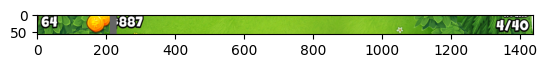

In [65]:
plt.imshow(topbarIm)

In [11]:
import keyboard, time, pyautogui
while True:
    if keyboard.is_pressed("`"):
        print(pyautogui.position())
        time.sleep(2)

Point(x=141, y=20)
Point(x=1488, y=76)


KeyboardInterrupt: 